In [111]:
# ML2 Final Project
# DS4420
# Christian Peterson, Shreesh Dassarkar, Jack Roberge
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pymc
import arviz as az
import pymc.sampling.jax as pymc_jax
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [170]:
nfl_data = pd.read_csv("/Users/Peterson/Documents/GitHub/DS4420-Final-Project/nfl_2019.csv")
print(len(nfl_data))

47548


C:\Users\Peterson\AppData\Local\Temp\ipykernel_8200\3948928638.py:1: DtypeWarning: Columns (42,167,168,169,170,175,176,179,180,183,184,189,190,191,192,195,196,199,200,204,205,206,219,220,221,222,223,224,227,228,232,233,234,239,241,242) have mixed types. Specify dtype option on import or set low_memory=False.
  nfl_data = pd.read_csv("/Users/Peterson/Documents/GitHub/DS4420-Final-Project/nfl_2019.csv")


(array([1.000e+00, 0.000e+00, 0.000e+00, 6.000e+00, 8.000e+00, 9.000e+00,
        1.100e+01, 1.800e+01, 2.600e+01, 4.900e+01, 1.070e+02, 1.550e+02,
        1.940e+02, 3.390e+02, 5.270e+02, 1.887e+03, 7.807e+03, 1.854e+04,
        7.246e+03, 4.474e+03, 2.121e+03, 1.126e+03, 4.900e+02, 1.680e+02,
        7.700e+01, 5.100e+01, 1.800e+01, 1.100e+01, 3.000e+00, 2.000e+00]),
 array([-13.49472   , -12.73673487, -11.97874973, -11.2207646 ,
        -10.46277947,  -9.70479433,  -8.9468092 ,  -8.18882407,
         -7.43083893,  -6.6728538 ,  -5.91486867,  -5.15688353,
         -4.3988984 ,  -3.64091327,  -2.88292813,  -2.124943  ,
         -1.36695787,  -0.60897273,   0.1490124 ,   0.90699753,
          1.66498267,   2.4229678 ,   3.18095293,   3.93893807,
          4.6969232 ,   5.45490833,   6.21289347,   6.9708786 ,
          7.72886373,   8.48684887,   9.244834  ]),
 <BarContainer object of 30 artists>)

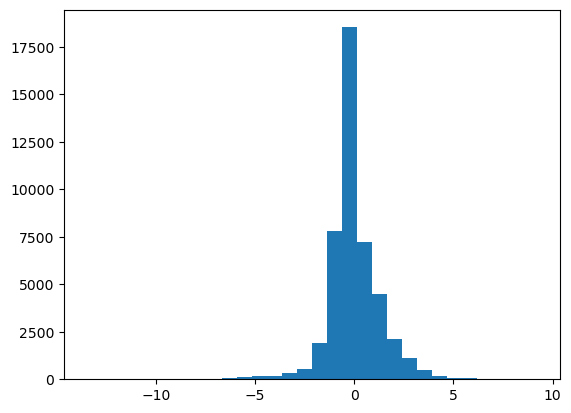

In [171]:
plt.hist(nfl_data["epa"], bins=30)

In [172]:
# Clean missing data
bool_df = nfl_data[["epa", "yardline_100", "down", "ydstogo", 
                    "quarter_seconds_remaining", "play_type"]]

# Remove where EPA is missing
nan = bool_df.loc[bool_df["epa"].isna()]
bool_df = bool_df.drop(index=nan.index)

# NEW - Remove where fields goals & punts are a play type
# b/c --> field goals/punts only really happen on 4th downs 
# (can break convergence b/c near perfect correlation 
# -> identifiability issue where sampler drifts between the 2 with a constant sum)
# also remove qb kneeling & spiking b/c they're rare --> hurts convergence from high variability
non_playtype = bool_df.loc[bool_df["play_type"].isin(["punt", "field_goal", "qb_kneel", "qb_spike"])]
bool_df = bool_df.drop(index=non_playtype.index)

# NaNs are insignificant reduction in DF size, so remove those rows
cols = ["epa", "yardline_100", "down", "ydstogo", 
                    "quarter_seconds_remaining", "play_type"]
for col in cols:
    nan = bool_df.loc[bool_df[col].isna()]
    print(f"{col}: {len(nan)}")
    bool_df = bool_df.drop(index=nan.index)

print(len(bool_df))

epa: 0
yardline_100: 60
down: 5875
ydstogo: 0
quarter_seconds_remaining: 0
play_type: 0
35942


In [173]:
print(bool_df.iloc[0])

epa                          0.86296
yardline_100                    75.0
down                             1.0
ydstogo                           10
quarter_seconds_remaining      900.0
play_type                       pass
Name: 198, dtype: object


In [174]:
print(set(bool_df["play_type"]))  
# note - we no longer have data for Kickoff & Extra point 
# (these are fine, i think extra point would skew the model)

{'pass', 'no_play', 'run'}


In [175]:
# Data cleaning / manipulation functions

def encode_x(x_df, categ_ttls):
    """
    Encode all the categorical features
    using the categorical column names by
    updating the DataFrame
    """
    for col in categ_ttls:
        categ_data = x_df[col].values.reshape(-1, 1)

        # Encode
        encoder = OneHotEncoder()
        categ_encoded = encoder.fit_transform(categ_data)

        # Handle multidimensional bools
        encoded_full = pd.DataFrame(
            categ_encoded.toarray(),
            columns=encoder.get_feature_names_out([col]),
            #index=x_df[col].index
            index=x_df.index
        )

        # Add to the df
        x_df = x_df.drop(columns=[col])
        x_df = pd.concat([x_df, encoded_full], axis=1)

    return x_df

def scale_df(x_train, y_train, x_test, y_test, min_max, std):
    """
    Scale a DataFrame's features by
    differentiating between columns that require
    min-max scaling and standardization
    """
    # Min-max columns
    minmax_scaler = MinMaxScaler()
    x_train[min_max] = minmax_scaler.fit_transform(x_train[min_max])  
    x_test[min_max] = minmax_scaler.transform(x_test[min_max])

    # Standardized columns
    std_scaler = StandardScaler()
    y_train = std_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    y_test = std_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

    return x_train, y_train, x_test, y_test, std_scaler

In [176]:
# Encode the play_type categorical variable
bool_df = encode_x(bool_df, ["down", "play_type"])

# Split the data into training and test sets
x_data = bool_df.drop(columns=["epa"])
y_data = bool_df["epa"]

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data,
                                                   test_size=0.2, random_state=42)

# Scale the data
minmax_cols = ["yardline_100", "ydstogo", "quarter_seconds_remaining"]
std_cols = ["epa"]
x_train, y_train, x_test, y_test, std_scaler = scale_df(x_train, y_train, x_test, y_test, 
                                            minmax_cols, std_cols)

In [169]:
# Create the model
df_down = x_train.iloc[:, [3, 4, 5, 6]]
#df_playtype = x_train.iloc[:, [7, 8, 9, 10, 11, 12, 13]]
df_playtype = x_train.iloc[:, [7, 8, 9]]

with pymc.Model() as epa_norm:
    # Weight Priors
    w0 = pymc.Normal("w0", mu=0, sigma=0.5)
    w_yardline = pymc.Normal("w_yardline", mu=1, sigma=0.5)
    w_ydstogo = pymc.Normal("w_ydstogo", mu=-0.5, sigma=0.3)
    w_qtrsecs = pymc.Normal("w_qtrsecs", mu=0.5, sigma=0.5)
    w_down = pymc.Normal("w_down", mu=-1, sigma=0.5, shape=df_down.shape[1])
    w_playtype = pymc.Normal("w_playtype", mu=0, sigma=1, shape=df_playtype.shape[1])

    # Calculate Mu
    mu = (
        w0 +
        w_yardline * x_train["yardline_100"] +
        w_ydstogo * x_train["ydstogo"] +
        w_qtrsecs * x_train["quarter_seconds_remaining"] +
        w_down @ df_down.T +
        w_playtype @ df_playtype.T 
    )

    # Create the Likelihood
    # Define sigma first
    sigma = pymc.InverseGamma("sigma", alpha=1.5, beta=1)
    epa_data = pymc.Normal("epa_data", mu=mu, sigma=sigma,
                           observed=y_train)  # likelihood

    # Obtain samples from posterior
    post_samples = pymc_jax.sample_numpyro_nuts(
                               draws=1000, 
                               tune=180,  # burn
                               chains=4,  # need these 4 to converge
                               target_accept=0.95,
                               #return_inferencedata=True
    )

  0%|          | 0/1180 [00:00<?, ?it/s]

  0%|          | 0/1180 [00:00<?, ?it/s]

  0%|          | 0/1180 [00:00<?, ?it/s]

  0%|          | 0/1180 [00:00<?, ?it/s]

In [177]:
# Obtain summary output to interpret coefficients
print(az.summary(post_samples, round_to=2))

               mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
w0             0.40  0.38   -0.29     1.13       0.01     0.01   1515.15   
w_yardline     0.06  0.02    0.02     0.11       0.00     0.00   3451.28   
w_ydstogo     -0.43  0.06   -0.56    -0.32       0.00     0.00   3682.60   
w_qtrsecs      0.00  0.02   -0.03     0.04       0.00     0.00   3414.54   
w_down[0]     -0.89  0.24   -1.33    -0.42       0.01     0.01   1014.53   
w_down[1]     -0.90  0.24   -1.35    -0.44       0.01     0.01    999.53   
w_down[2]     -0.93  0.24   -1.37    -0.45       0.01     0.01   1008.03   
w_down[3]     -0.87  0.25   -1.35    -0.42       0.01     0.01   1015.18   
w_playtype[0]  0.51  0.40   -0.23     1.26       0.01     0.01   1304.84   
w_playtype[1]  0.58  0.40   -0.17     1.33       0.01     0.01   1299.88   
w_playtype[2]  0.51  0.40   -0.24     1.26       0.01     0.01   1302.54   
sigma          1.00  0.00    0.99     1.01       0.00     0.00   4296.74   

           

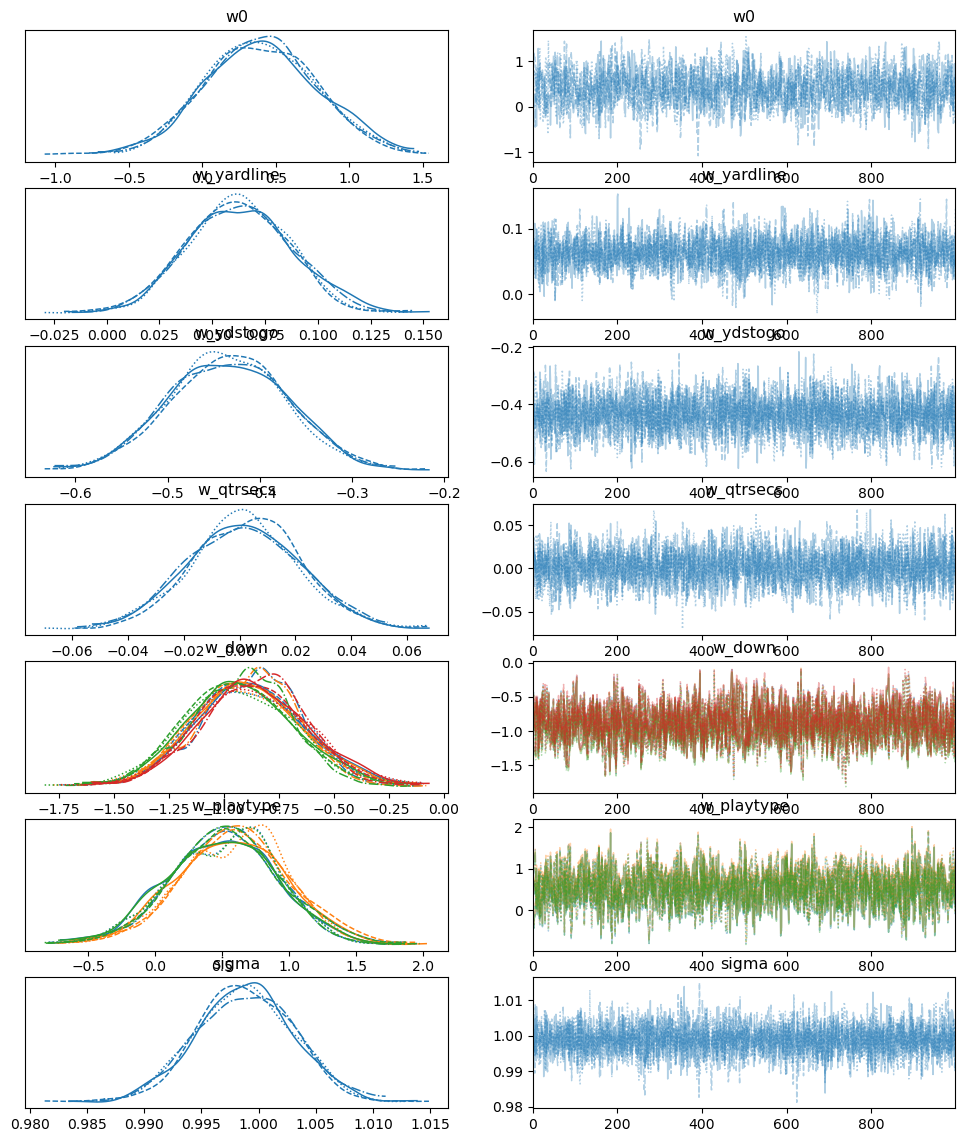

In [178]:
# Obtain plots to assess distributions & chain convergence
az.plot_trace(post_samples)
plt.show()

Sampling: [epa_data]


Output()

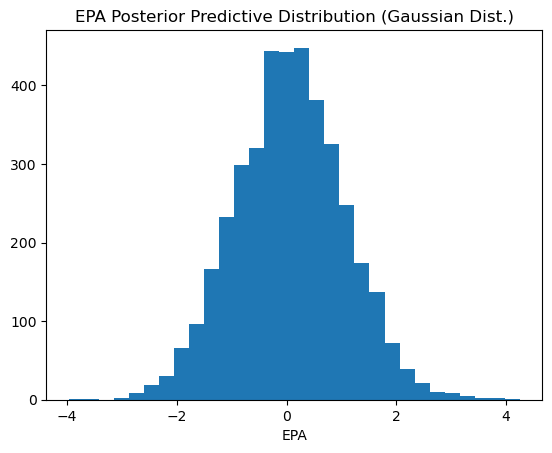

In [73]:
# Visualize the Posterior Predictive samples
with epa_norm:
    preds_norm = pymc.sample_posterior_predictive(post_samples, var_names=["epa_data"])

# Plot the histogram
plt.hist(preds_norm.posterior_predictive["epa_data"][:, :, 0].values.ravel(), bins=30)
plt.title("EPA Posterior Predictive Distribution (Gaussian Dist.)")
plt.xlabel("EPA")
plt.show()

In [195]:
# Find the dimensions to reshape categorical variables by
n_samples = post_samples.posterior["w0"].values.size  # chains * draws

# Obtain test splits for categorical data
df_down_test = x_test.iloc[:, [3, 4, 5, 6]]
df_playtype_test = x_test.iloc[:, [7, 8, 9]]

# Reshape all parameters for predictions
w0_flat = post_samples.posterior["w0"].values.flatten()
w_yardline_flat = post_samples.posterior["w_yardline"].values.flatten()
w_ydstogo_flat = post_samples.posterior["w_ydstogo"].values.flatten()
w_qtrsecs_flat = post_samples.posterior["w_qtrsecs"].values.flatten()
w_down_flat = post_samples.posterior["w_down"].values.reshape(n_samples, -1)
w_playtype_flat = post_samples.posterior["w_playtype"].values.reshape(n_samples, -1)

# Calculate predictions for posterior samples
mu_test = (
    w0_flat[:, None] +
    w_yardline_flat[:, None] * x_test["yardline_100"].values +
    w_ydstogo_flat[:, None] * x_test["ydstogo"].values +
    w_qtrsecs_flat[:, None] * x_test["quarter_seconds_remaining"].values +
    w_down_flat @ df_down_test.values.T +
    w_playtype_flat @ df_playtype_test.values.T
)

# Obtain the predictions to compare with the actual (it is a distribution, so average it)
# Average across all posterior samples
y_pred_standardized = mu_test.mean(axis=0)
y_pred = std_scaler.inverse_transform(y_pred_standardized.reshape(-1, 1)).flatten()

# After making predictions, inverse-transform y_test
y_test = std_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Check to make sure shape is equivalent
y_pred_lower = np.percentile(mu_test, 2.5, axis=0)
y_pred_upper = np.percentile(mu_test, 97.5, axis=0)

print(f"Predictions shape: {y_pred.shape}")
print(f"Expected shape: {y_test.shape}")

Predictions shape: (7189,)
Expected shape: (7189,)


In [196]:
# EPA
print(y_pred)
print(y_test)

[0.03905256 0.10234134 0.05544793 ... 0.01739238 0.07515206 0.07540451]
[-0.76587975  0.54141134  0.5071931  ...  0.7620003   2.098349
 -0.7262483 ]


In [197]:
print(min(y_test))
print(max(y_test))
print()

print(min(y_pred_standardized))
print(max(y_pred_standardized))
print()

print(min(y_pred))
print(max(y_pred))
print()

print(np.mean(y_test))
print(np.mean(y_train))
print(np.mean(y_pred))

-11.1192
7.8900285

-0.3362432647891158
0.16047433274558234

-0.45763335624470647
0.24298819017875228

0.028889810279068992
1.11203780854883e-18
0.01674613206253278



Test Set Performance:
  R²: 0.0020
  RMSE: 1.3851
  MAE: 0.9653


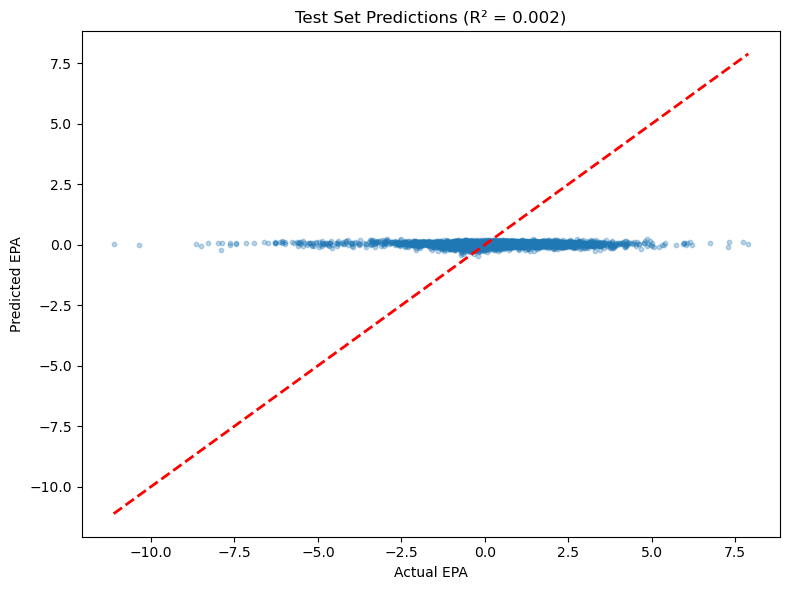

In [198]:
# NEW - Assess Cross Validation data
# Calculate metrics
test_r2 = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)

print(f"\nTest Set Performance:")
print(f"  R²: {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE: {test_mae:.4f}")

# Plot predictions vs actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual EPA")
plt.ylabel("Predicted EPA")
plt.title(f"Test Set Predictions (R² = {test_r2:.3f})")
plt.tight_layout()
plt.show()

Target Variable (EPA) Statistics:
  Mean: 0.0000
  Std: 1.0000
  Min: -9.5791
  Max: 6.5425

Predictions Statistics:
  Mean: 0.0167
  Std: 0.0725
  Min: -0.4576
  Max: 0.2430

Your Model R²: 0.0020
Mean Baseline R²: -0.0004
Beating baseline: True


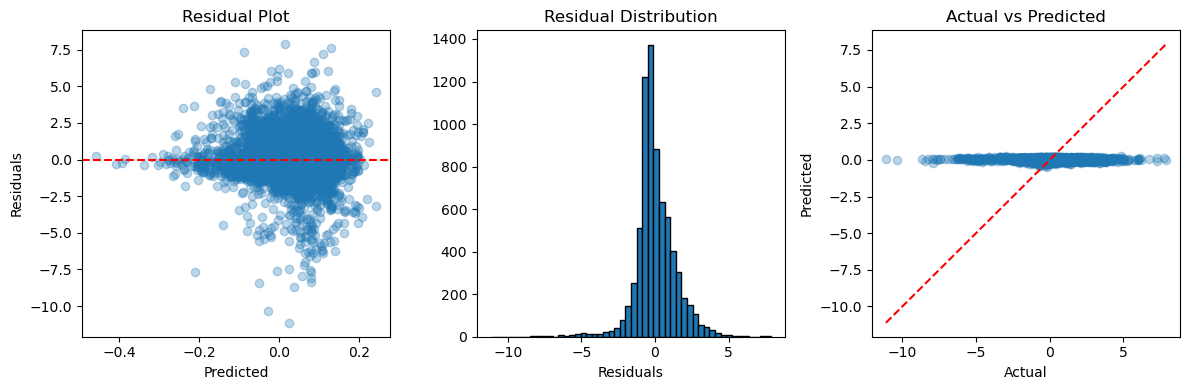

In [199]:
# Check basic statistics
print("Target Variable (EPA) Statistics:")
print(f"  Mean: {y_train.mean():.4f}")
print(f"  Std: {y_train.std():.4f}")
print(f"  Min: {y_train.min():.4f}")
print(f"  Max: {y_train.max():.4f}")

# Compare to predictions
print("\nPredictions Statistics:")
print(f"  Mean: {y_pred.mean():.4f}")
print(f"  Std: {y_pred.std():.4f}")
print(f"  Min: {y_pred.min():.4f}")
print(f"  Max: {y_pred.max():.4f}")

# Calculate baseline performance
y_mean_baseline = np.full_like(y_test, y_train.mean())
baseline_r2 = r2_score(y_test, y_mean_baseline)
print(f"\nYour Model R²: {test_r2:.4f}")
print(f"Mean Baseline R²: {baseline_r2:.4f}")
print(f"Beating baseline: {test_r2 > baseline_r2}")

# Look at residuals
residuals = y_test - y_pred
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.subplot(1, 3, 2)
plt.hist(residuals, bins=50, edgecolor='black')
plt.xlabel("Residuals")
plt.title("Residual Distribution")

plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.tight_layout()
plt.show()